In [1]:
import numpy as np
import sys
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))
DATA_DIR = PROJECT_ROOT / "data"

df = pd.read_csv(DATA_DIR / "manifests/cityscapes_pairs.csv")
df.head()

,split,city,image_path,mask_path
0,train,aachen,leftImg8bit/train/aachen/aachen_000000_000019_...,gtFine/train/aachen/aachen_000000_000019_gtFin...
1,train,aachen,leftImg8bit/train/aachen/aachen_000001_000019_...,gtFine/train/aachen/aachen_000001_000019_gtFin...
2,train,aachen,leftImg8bit/train/aachen/aachen_000002_000019_...,gtFine/train/aachen/aachen_000002_000019_gtFin...
3,train,aachen,leftImg8bit/train/aachen/aachen_000003_000019_...,gtFine/train/aachen/aachen_000003_000019_gtFin...
4,train,aachen,leftImg8bit/train/aachen/aachen_000004_000019_...,gtFine/train/aachen/aachen_000004_000019_gtFin...


In [3]:
df['split'].value_counts()

split
train    2975
val       500
Name: count, dtype: int64

(-0.5, 2047.5, 1023.5, -0.5)

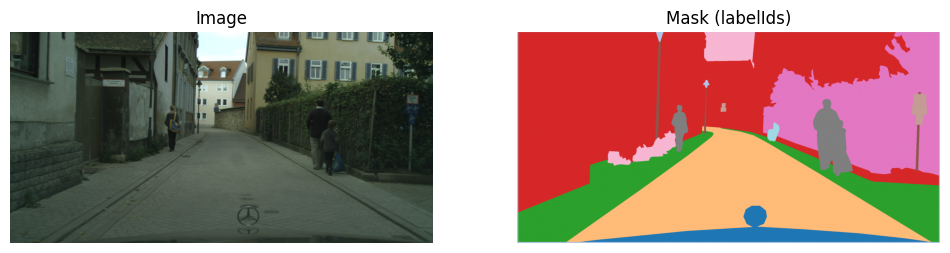

In [4]:
row = df.sample(1).iloc[0]

img_path = PROJECT_ROOT / "data" / row.image_path
mask_path = PROJECT_ROOT / "data" / row.mask_path

img = np.array(Image.open(img_path))
mask = np.array(Image.open(mask_path))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="tab20")
plt.title("Mask (labelIds)")
plt.axis("off")

In [5]:
unique_values = np.unique(mask)
unique_values

array([ 1,  3,  4,  7,  8, 11, 17, 20, 21, 22, 23, 24, 33], dtype=uint8)

In [6]:
all_labels = set()

for path in df["mask_path"].sample(100):
    mask = np.array(Image.open(PROJECT_ROOT / "data" / path))
    all_labels.update(np.unique(mask))

sorted(all_labels)

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 11,
 12,
 13,
 15,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33]

In [7]:
img.shape, mask.shape

((1024, 2048, 3), (1024, 2048))

In [8]:
from collections import Counter
import numpy as np
from PIL import Image
from tqdm import tqdm
from src.data.cityscapes_mapping import GROUPS, map_mask_to_groups

counts = Counter()

for path in tqdm(df["mask_path"]):

    mask = np.array(Image.open(PROJECT_ROOT / "data" / path))
    mask = map_mask_to_groups(mask)

    unique, c = np.unique(mask, return_counts=True)

    for u, n in zip(unique, c):
        counts[int(u)] += int(n)

total_pixels = sum(counts.values())

for k,v in counts.items():
    print(k, GROUPS[k], v/total_pixels)

  0%|          | 0/3475 [00:00<?, ?it/s]

100%|██████████| 3475/3475 [01:21<00:00, 42.43it/s]

0 flat 0.387292568837996
1 human 0.01216841855495096
2 vehicle 0.07322486726500148
3 construction 0.2171710587920045
4 object 0.018080739906365922
5 nature 0.15234454010887968
6 sky 0.034681497615018334
7 void 0.10503630891978312


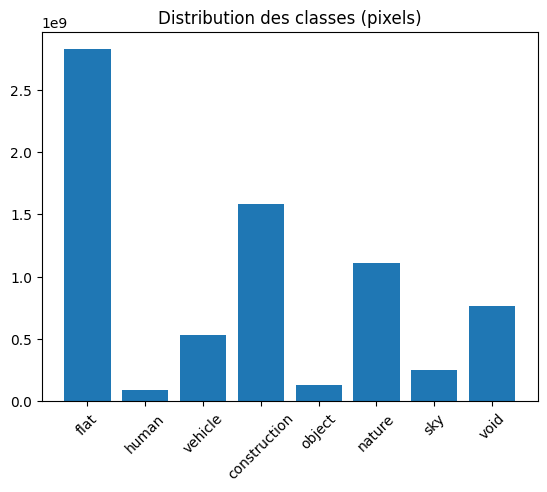

In [9]:
import matplotlib.pyplot as plt

labels = [GROUPS[k] for k in counts.keys()]
values = [counts[k] for k in counts.keys()]

plt.bar(labels, values)
plt.title("Distribution des classes (pixels)")
plt.xticks(rotation=45)
plt.show()

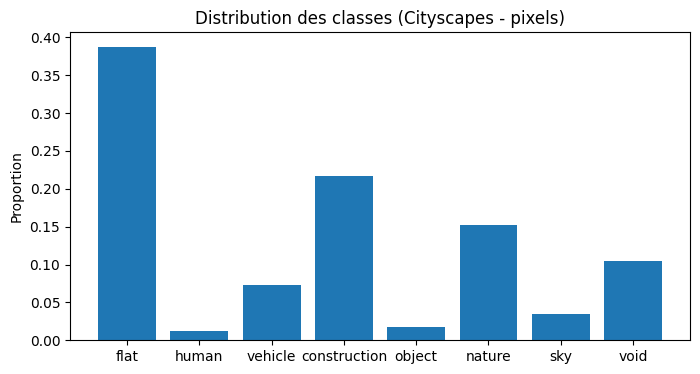

In [10]:
labels = [
"flat","human","vehicle","construction",
"object","nature","sky","void"
]

values = [
0.3872,0.0121,0.0732,0.2171,
0.0180,0.1523,0.0346,0.1050
]

plt.figure(figsize=(8,4))
plt.bar(labels, values)
plt.title("Distribution des classes (Cityscapes - pixels)")
plt.ylabel("Proportion")
plt.show()